<a href="https://colab.research.google.com/github/huiying8888/data-analytics/blob/main/Capstone/Insurance_Claims_Capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Load Data

In [120]:
import pandas as pd
import numpy as np

# Sourced from Healthcare.gov transparency in coverage PUFs, 2023 - https://data.healthcare.gov/datasets?fulltext=transparency%20in%20coverage
url = "https://github.com/huiying8888/data-analytics/raw/refs/heads/main/Capstone/transparency_in_coverage_PUF_2023.xlsx"
df = pd.read_excel(url, sheet_name="Transparency 2023 - Ind QHP", header= 2)

# Cleaning Data

In [121]:
# Replace special values
df = df.replace(["*", "**", "***", "N/A"], np.nan)


# These are the columns we're interested in and need to clean empty rows from
cols = [
"Plan_Number_Claims_Received",
"Plan_Number_Claims_Denied",
"Average Monthly Enrollment",
"Plan_Number_Claims_Denied_Other",
"Plan_Number_Claims_Denied_Referral_Required",
"Plan_Number_Claims_Denied_Out_of_Network",
"Plan_Number_Claims_Denied_Out_of_Network",
"Plan_Number_Claims_Denied_Services_Excluded",
"Plan_Number_Claims_Denied_Not_Medically_Necessary_Excl_Behavioral_Health",
"Plan_Number_Claims_Denied_Not_Medically_Necessary_Behavioral_Health_Only",
"Average Monthly Disenrollment"
]

# Convert the rows of our columns from string to number, if any data fails to do this (such as remaining '***'), make it NaN
for col in cols:
  df[col] = pd.to_numeric(df[col], errors="coerce")

# Drop missing values - Missing values mean the plan will not be renewed with CMS
df = df.dropna(subset=cols)

# Filter out data that would cause a divide by zero
df = df[df["Plan_Number_Claims_Received"] > 0]
df = df[df["Average Monthly Enrollment"] > 0]

# Create variables
df["denial_rate"] = df["Plan_Number_Claims_Denied"] / df["Plan_Number_Claims_Received"]

df["disenrollment_rate"] = df["Average Monthly Disenrollment"] / df["Average Monthly Enrollment"]

# Check result
df[["denial_rate", "disenrollment_rate"]].head()



,denial_rate,disenrollment_rate
10,0.078052,0.142259
11,0.082293,0.167763
16,0.227608,0.137636
17,0.217124,0.085369
18,0.234109,0.135465


# Summary Function

In [122]:
def summarize_rates(data):
  return data[["denial_rate", "disenrollment_rate"]].describe()

summarize_rates(df)


,denial_rate,disenrollment_rate
count,941.000000,941.000000
mean,0.160494,0.150225
std,0.085741,0.049502
min,0.013175,0.061576
25%,0.107509,0.116411
50%,0.147360,0.140097
75%,0.203491,0.168009
max,0.493979,0.526316


# Overall Denial Rate

In [123]:
overall_denial = df["Plan_Number_Claims_Denied"].sum() / df["Plan_Number_Claims_Received"].sum()
overall_denial


np.float64(0.1587990101620716)

# Variation Across Plans

In [124]:
df["denial_rate"].describe()

,denial_rate
count,941.000000
mean,0.160494
std,0.085741
min,0.013175
25%,0.107509
50%,0.147360
75%,0.203491
max,0.493979


In [125]:
# Denial rate per company (issuer)
df.groupby("Issuer_Name")["denial_rate"].mean().sort_values()

,denial_rate
Issuer_Name,
"CareFirst BlueChoice, Inc.",0.027531
Oscar Insurance Corporation of Ohio,0.028239
Oscar Buckeye State Insurance Corp.,0.030568
Group Hospitalization and Medical Services Inc.,0.032933
"Oscar Health Plan, Inc.",0.035949
...,...
Ambetter of Magnolia Inc.,0.386800
Ambetter of Peach State Inc.,0.396877
Buckeye Community Health Plan,0.414242


# Top 10 denial insurance companies

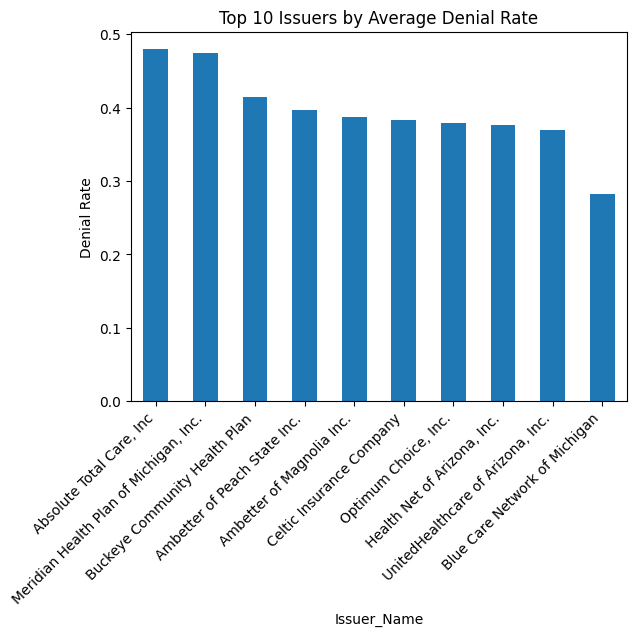

In [126]:
import matplotlib.pyplot as plt

top_10 = df.groupby("Issuer_Name")["denial_rate"].mean().sort_values(ascending=False).head(10)

top_10.plot(kind="bar")
plt.title("Top 10 Issuers by Average Denial Rate")
plt.ylabel("Denial Rate")
plt.xticks(rotation=45, ha="right")
plt.show()

# Bottom 10

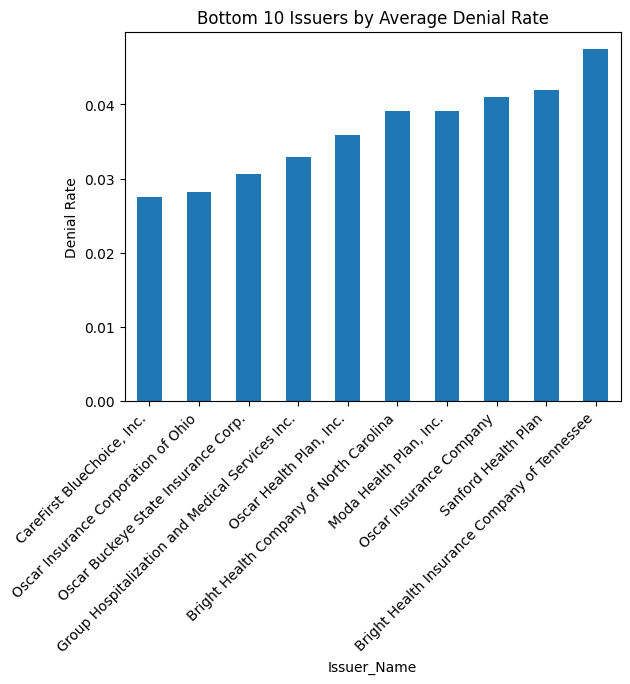

In [127]:
bottom10 = df.groupby("Issuer_Name")["denial_rate"].mean().sort_values().head(10)

bottom10.plot(kind="bar")
plt.title("Bottom 10 Issuers by Average Denial Rate")
plt.ylabel("Denial Rate")
plt.xticks(rotation=45, ha="right")
plt.show()

# Reasons For In-Network Claims Denials Among HealthCare.gov Plans, 2023


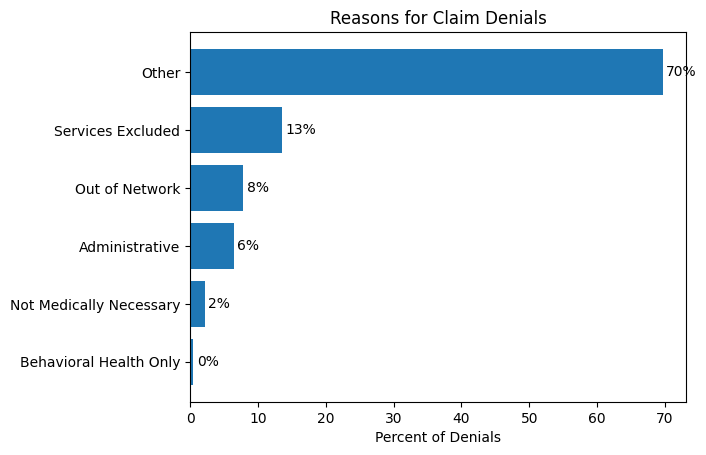

In [128]:
reasons = {
"Other": df["Plan_Number_Claims_Denied_Other"].sum(),
"Administrative": df["Plan_Number_Claims_Denied_Referral_Required"].sum(),
"Out of Network": df["Plan_Number_Claims_Denied_Out_of_Network"].sum(),
"Services Excluded": df["Plan_Number_Claims_Denied_Services_Excluded"].sum(),
"Not Medically Necessary": df["Plan_Number_Claims_Denied_Not_Medically_Necessary_Excl_Behavioral_Health"].sum(),
"Behavioral Health Only": df["Plan_Number_Claims_Denied_Not_Medically_Necessary_Behavioral_Health_Only"].sum()
}

reasons_df = pd.DataFrame(list(reasons.items()), columns=["Reason", "Total"])

# Convert to percentage
reasons_df["Percent"] = reasons_df["Total"] / reasons_df["Total"].sum() * 100

# Sort descending
reasons_df = reasons_df.sort_values(by="Percent", ascending=True)

plt.barh(reasons_df["Reason"], reasons_df["Percent"])

plt.xlabel("Percent of Denials")
plt.title("Reasons for Claim Denials")

# Add labels on bars
for i, v in enumerate(reasons_df["Percent"]):
  plt.text(v + 0.5, i, f"{v:.0f}%", va="center")

plt.show()

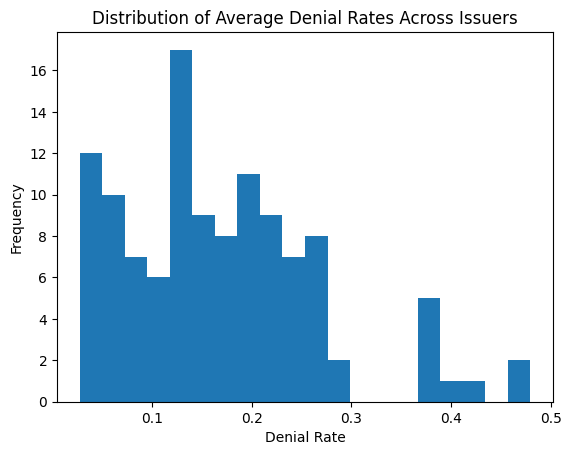

In [129]:
# Show a bellcurve for denial rate by company

df.groupby("Issuer_Name")["denial_rate"].mean().plot(kind="hist", bins=20)
plt.title("Distribution of Average Denial Rates Across Issuers")
plt.xlabel("Denial Rate")
plt.show()


# Denial Rate by Metal level

In [130]:
df.groupby("Metal_Level")["denial_rate"].mean().sort_values()

,denial_rate
Metal_Level,
Platinum,0.103100
Bronze Expanded,0.150377
Silver,0.158927
Gold,0.170650
Catastrophic,0.183145
Bronze,0.202554


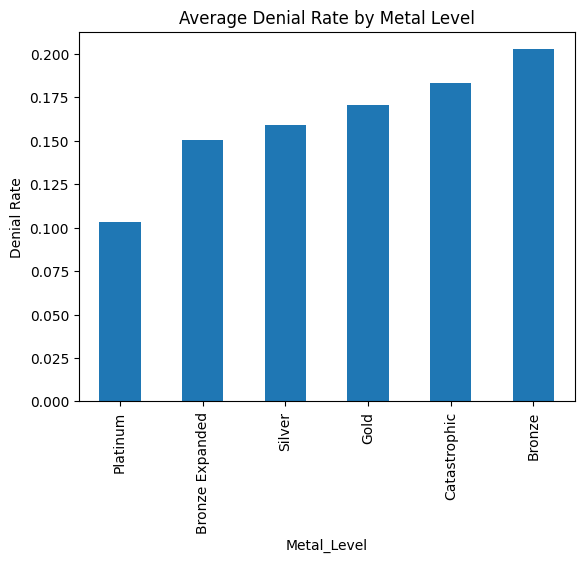

In [131]:
df.groupby("Metal_Level")["denial_rate"].mean().sort_values().plot(kind="bar")
plt.title("Average Denial Rate by Metal Level")
plt.ylabel("Denial Rate")
plt.show()

# Relationship scatter plots

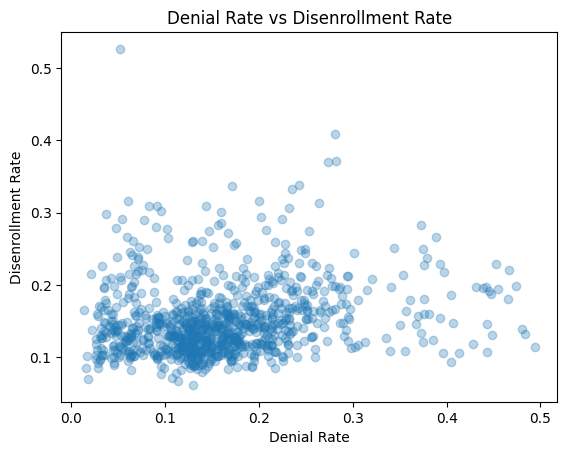

In [132]:
plt.scatter(df["denial_rate"], df["disenrollment_rate"], alpha=0.3)
plt.xlabel("Denial Rate")
plt.ylabel("Disenrollment Rate")
plt.title("Denial Rate vs Disenrollment Rate")
plt.show()

# Linear Regression

In [133]:
import statsmodels.api as sm

x = df[["denial_rate"]]
x = sm.add_constant(x)
y = df["disenrollment_rate"]

model = sm.OLS(y, x).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:     disenrollment_rate   R-squared:                       0.037
Model:                            OLS   Adj. R-squared:                  0.036
Method:                 Least Squares   F-statistic:                     35.88
Date:                Mon, 27 Apr 2026   Prob (F-statistic):           2.99e-09
Time:                        01:01:59   Log-Likelihood:                 1511.3
No. Observations:                 941   AIC:                            -3019.
Df Residuals:                     939   BIC:                            -3009.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.1324      0.003     39.370      

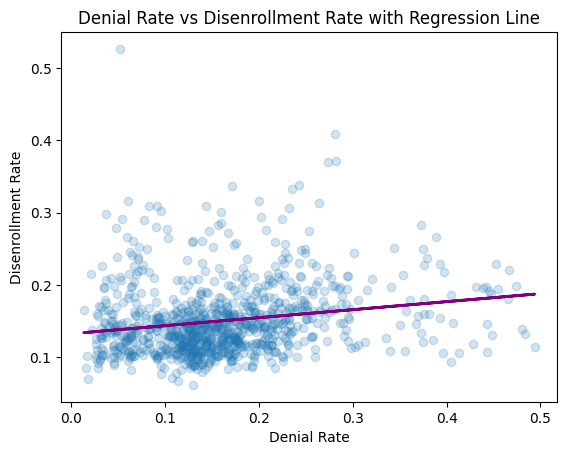

In [134]:
plt.scatter(df["denial_rate"], df["disenrollment_rate"], alpha=0.2)

plt.plot(
df["denial_rate"],
model.predict(x),
linewidth=2,
color='purple'
)

plt.xlabel("Denial Rate")
plt.ylabel("Disenrollment Rate")
plt.title("Denial Rate vs Disenrollment Rate with Regression Line")
plt.show()

The regression results show that denial rate has a positive and statistically significant association with disenrollment rate. The coefficient indicates that higher denial rates are associated with slightly higher disenrollment. However, the low R-squared value (0.028) suggests that denial rates explain only a small portion of the variation in disenrollment.

While denial rates are significantly related to disenrollment, the relationship is relatively weak. This suggests that other factors beyond claim denials likely play a larger role in influencing whether consumers leave a health plan.